In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")  

In [2]:
import shutil
import os

raw_path = r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\raw"
processed_path = r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed"

files = [
    "01_fund_master.csv",
    "03_aum_by_fund_house.csv",
    "04_monthly_sip_inflows.csv",
    "05_category_inflows.csv",
    "06_industry_folio_count.csv",
    "09_portfolio_holdings.csv",
    "10_benchmark_indices.csv",
    "axis_nav.csv",
    "hdfc_nav.csv",
    "icici_nav.csv",
    "kotak_nav.csv",
    "nippon_nav.csv",
    "sbi_nav.csv"
]

for file in files:
    shutil.copy(
        os.path.join(raw_path, file),
        os.path.join(processed_path, file)
    )

print("All remaining datasets copied successfully!")  

All remaining datasets copied successfully!


In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\02_nav_history.csv"
)

fund = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\01_fund_master.csv"
) 

In [11]:
# Step 2

# Convert date.

nav["date"] = pd.to_datetime(nav["date"])
# Step 3

# Sort.

nav = nav.sort_values(["amfi_code","date"]) 

# Step 4

# Compute daily returns.

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
# Step 5

# Remove first NaN.

returns = nav.dropna(subset=["daily_return"]) 

# Step 6

# Compute VaR & CVaR

results = []

for code, df in returns.groupby("amfi_code"):

    var95 = np.percentile(df["daily_return"],5)

    cvar95 = df.loc[
        df["daily_return"]<=var95,
        "daily_return"
    ].mean()

    results.append([
        code,
        var95,
        cvar95
    ]) 

# Step 7

# Create report.

var_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
) 

# Step 8

# Merge with scheme names.

var_report = var_report.merge(
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
) 

# Step 9

# Rearrange columns.

var_report = var_report[
[
"amfi_code",
"scheme_name",
"VaR_95",
"CVaR_95"
]
]

# Step 10

# Save.

var_report.to_csv(
r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\var_cvar_report.csv",
index=False
) 

In [13]:
#  Task 2: Rolling 90-Day Sharpe Ratio
# Objective

# Compute:   Rolling Sharpe =  Rolling Mean(Return) / Rolling std(Return) * sqroot(252)
# using a 90-day rolling window.

# Then plot the Sharpe Ratio over time for 5 key funds. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
nav = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\02_nav_history.csv"
)

fund = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\01_fund_master.csv"
) 

In [21]:
# Step 3: Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Step 4: Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Step 5: Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
) 

# Step 6: Calculate Rolling 90-Day Sharpe Ratio
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: (
               x.rolling(90).mean()
               /
               x.rolling(90).std()
           ) * np.sqrt(252)
       )
)

# This calculates the Sharpe Ratio for every fund.

# Step 7: Choose 5 funds

# Since your assignment says 5 key funds, use the five major fund houses you already have:

# Load scheme performance data
performance = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\07_scheme_performance.csv"
)

# Select Top 5 funds based on AUM
top5 = performance.sort_values(
    by="aum_crore",
    ascending=False
).head(5)

# Get AMFI codes of Top 5 funds
top5_codes = top5["amfi_code"].tolist()

# Filter NAV data for only Top 5 funds
plot_data = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

# Merge scheme names for plotting
plot_data = plot_data.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Display selected funds
print(top5[["scheme_name", "aum_crore"]]) 

                                          scheme_name  aum_crore
35  Mirae Asset Emerging Bluechip Fund - Regular -...      49046
21      Kotak Emerging Equity Fund - Regular - Growth      47469
17     Nippon India Small Cap Fund - Regular - Growth      43630
37         DSP Top 100 Equity Fund - Regular - Growth      41828
32                UTI Mid Cap Fund - Regular - Growth      41728


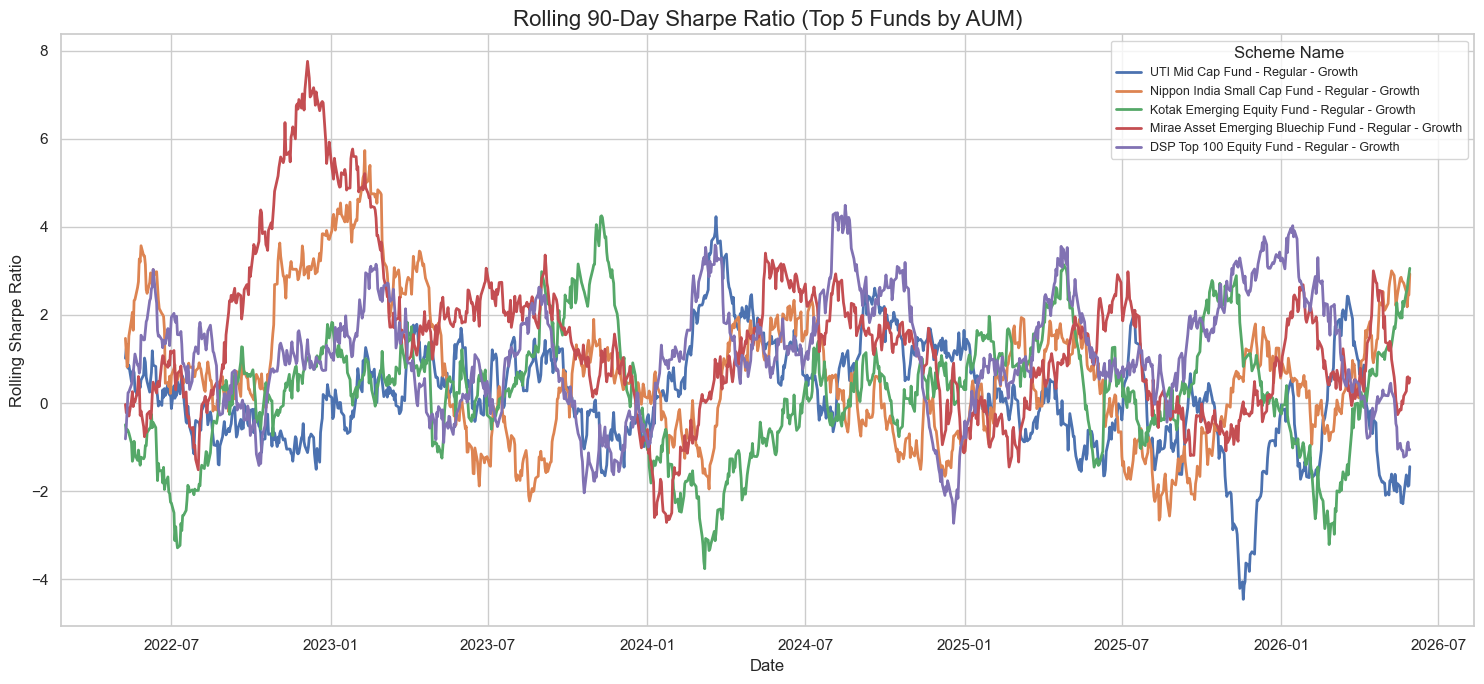

In [23]:
plt.figure(figsize=(15,7))

for code, df in plot_data.groupby("amfi_code"):

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        linewidth=2,
        label=df["scheme_name"].iloc[0]
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds by AUM)", fontsize=16)

plt.xlabel("Date", fontsize=12)

plt.ylabel("Rolling Sharpe Ratio", fontsize=12)

plt.legend(title="Scheme Name", fontsize=9)

plt.grid(True)

plt.tight_layout()

# Save chart
plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()   

In [30]:
# Task 3: Investor Cohort Analysis
# Objective

# Group investors by their first transaction year (their cohort), then compute:

# ✅ Average SIP amount
# ✅ Total amount invested
# ✅ Top fund preference for each cohort

# Finally, save the results as a report.

# Step 1: Load the processed dataset
import pandas as pd

transactions = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\08_investor_transactions.csv"
)

fund = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\01_fund_master.csv"
) 

# Step 2: Convert date
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Step 3: Find each investor's first transaction year (Cohort Year)
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
) 

# Step 4: Average SIP Amount per Cohort
sip_avg = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

# Step 5: Total Investment per Cohort
total_investment = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
) 

# Step 6: Top Fund Preference per Cohort

# Count how many transactions each fund received.

fund_pref = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transactions")
)

# Find the most preferred fund.

top_pref = (
    fund_pref
    .sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
) 

# Merge scheme names.

top_pref = top_pref.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
) 

# Step 7: Combine Everything
cohort_report = (
    sip_avg
    .merge(total_investment, on="cohort_year")
    .merge(
        top_pref[
            ["cohort_year", "scheme_name"]
        ],
        on="cohort_year"
    )
)

cohort_report.rename(
    columns={
        "scheme_name": "top_fund_preference"
    },
    inplace=True
) 

# Step 8: Display Results
cohort_report 


,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.885825,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [31]:
cohort_report.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\investor_cohort_analysis.csv",
    index=False
)  

In [32]:
# Task 4: SIP Continuity Analysis
# Objective

# For investors with 6 or more SIP transactions:

# Calculate the average gap (days) between SIP transactions.
# Flag investors with average gap > 35 days as "At-Risk".
# Step 1: Load dataset
import pandas as pd

transactions = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\08_investor_transactions.csv"
)

# Step 2: Convert date
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Step 3: Filter only SIP transactions
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

# Step 4: Sort data
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

# Step 5: Calculate gap between consecutive SIPs
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

# Step 6: Keep investors with at least 6 SIP transactions
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_count[
    sip_count["sip_count"] >= 6
]
# Step 7: Calculate average gap
avg_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index(name="avg_gap_days")
)
# Step 8: Merge
continuity = eligible.merge(
    avg_gap,
    on="investor_id"
)
# Step 9: Flag At-Risk Investors
continuity["status"] = continuity["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Regular"
)

# Step 10: Display
continuity.head() 

,investor_id,sip_count,avg_gap_days,status
0,INV000004,6,85.400000,At-Risk
1,INV000008,6,70.400000,At-Risk
2,INV000010,6,64.800000,At-Risk
3,INV000011,7,40.166667,At-Risk
4,INV000012,8,57.000000,At-Risk


In [33]:
continuity.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sip_continuity_analysis.csv",
    index=False
) 

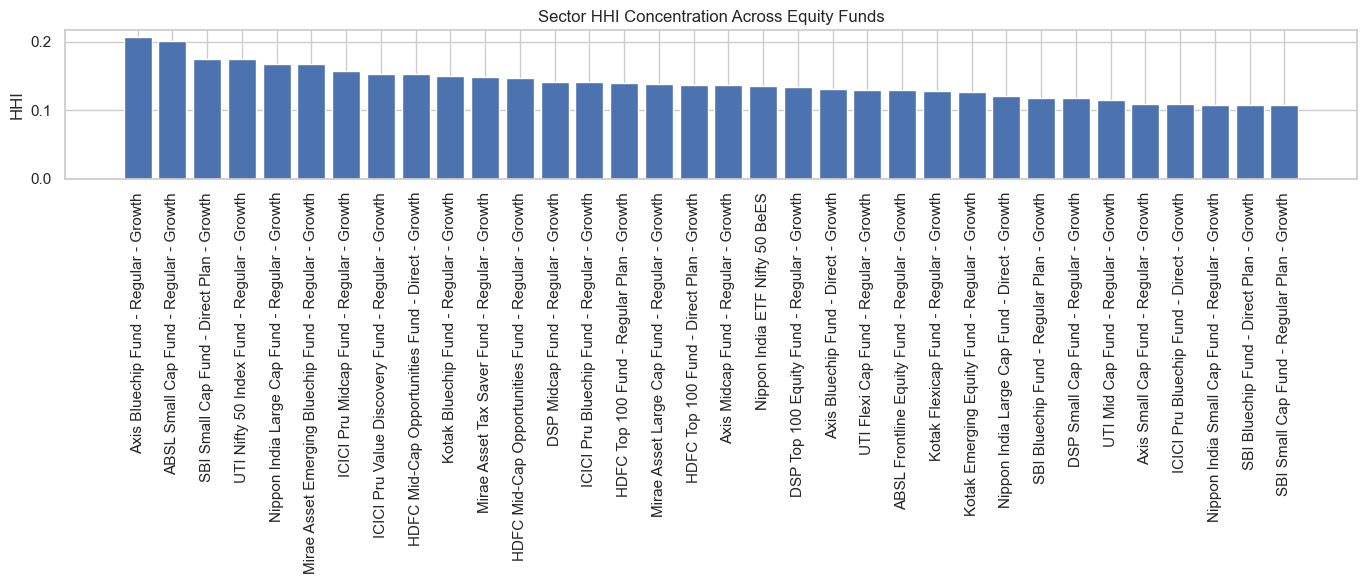

In [34]:
# Task 6: Sector HHI Concentration
# Objective

# Calculate the Herfindahl-Hirschman Index (HHI) for each fund.

# Formula:
# HHI=∑(weighti​)2 
# where weight_i is the portfolio weight of each stock (expressed as a proportion, not a percentage).

# Higher HHI = More concentrated portfolio.

# Lower HHI = Better diversified portfolio.

# Step 1: Load Data
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\09_portfolio_holdings.csv"
)

fund = pd.read_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\data\processed\01_fund_master.csv"
)

# Step 2: Convert percentage to proportion
holdings["weight"] = holdings["weight_pct"] / 100

# Step 3: Calculate HHI
hhi = (
    holdings
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

# Step 4: Merge Scheme Names
hhi = hhi.merge(
    fund[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

# Step 5: Keep Equity Funds
equity_hhi = hhi[
    hhi["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
]

# Step 6: Sort
equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
)

# Step 7: Display
equity_hhi

# Step 8: Plot
plt.figure(figsize=(14,6))

plt.bar(
    equity_hhi["scheme_name"],
    equity_hhi["HHI"]
)

plt.xticks(rotation=90)

plt.title("Sector HHI Concentration Across Equity Funds")

plt.ylabel("HHI")

plt.tight_layout()

plt.savefig(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sector_hhi.png",
    dpi=300
)

plt.show()

# Step 9: Save
equity_hhi.to_csv(
    r"C:\Users\eswar\OneDrive\Desktop\Project Folder\reports\sector_hhi_report.csv",
    index=False
)



In [35]:
# Task 7: Write 5 Advanced Insights

# In a Markdown cell in your notebook, write insights based on your results. Customize the wording to match your outputs.

# Insight 1 – VaR & CVaR 
# Funds with the largest negative VaR and CVaR values exhibit the highest downside risk. These schemes are more vulnerable during adverse market conditions and may be better suited to investors with a higher risk tolerance. 

# Insight 2 – Rolling Sharpe Ratio
# The rolling 90-day Sharpe Ratio fluctuated over time across the selected funds, reflecting changing risk-adjusted performance. Funds with consistently higher Sharpe ratios demonstrated more stable returns relative to risk.

# Insight 3 – Investor Cohorts
# Investor cohort analysis showed differences in investment behavior across entry years. 

# Insight 4 – SIP Continuity
# Most investors maintained regular SIP intervals, while investors with an average gap exceeding 35 days were identified as at-risk. These investors may require engagement strategies to improve investment continuity.

# Insight 5 – Portfolio Concentration
# The HHI analysis showed varying levels of portfolio concentration among equity funds. Funds with higher HHI values are more concentrated in fewer holdings, while lower HHI values indicate greater diversification and potentially lower concentration risk.

